<a href="https://colab.research.google.com/github/srithikak2008/Machine-Learning---Practical/blob/main/Week7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Model Accuracy Score ---
Accuracy: 0.465

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.22      0.32       113
           1       0.44      0.78      0.56        87

    accuracy                           0.47       200
   macro avg       0.50      0.50      0.44       200
weighted avg       0.51      0.47      0.42       200


Saved high-resolution plot structure -> decision_tree.png


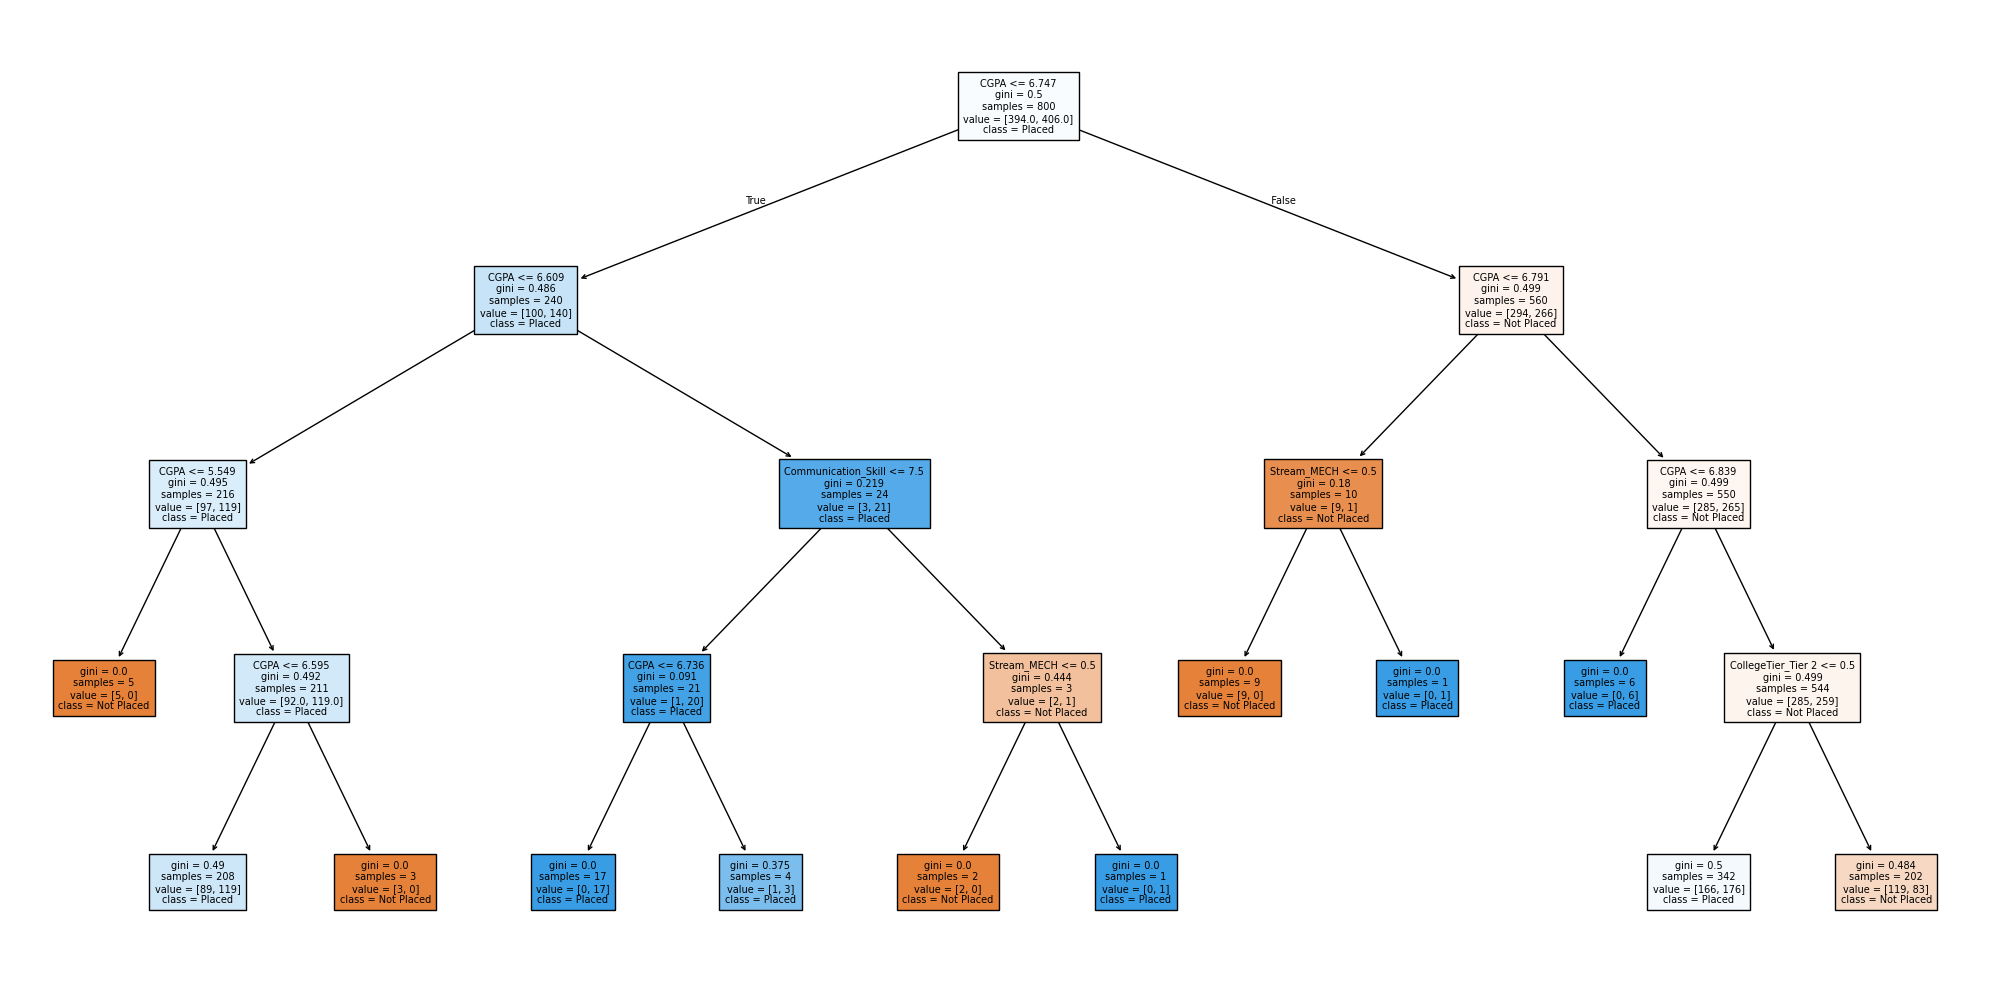

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# Create a mock dataset out of thin air so we don't need any external files
np.random.seed(42)
data = {
    'CGPA': np.random.uniform(5.5, 9.9, 1000),
    'IQ': np.random.randint(80, 140, 1000),
    'Aptitude_Score': np.random.randint(40, 100, 1000),
    'Communication_Skill': np.random.randint(1, 10, 1000),
    'Internships': np.random.randint(0, 4, 1000),
    'Gender': np.random.choice(['Male', 'Female'], 1000),
    'City': np.random.choice(['Metro', 'Non-Metro'], 1000),
    'CollegeTier': np.random.choice(['Tier 1', 'Tier 2', 'Tier 3'], 1000),
    'Stream': np.random.choice(['CSE', 'IT', 'ECE', 'MECH', 'CIVIL'], 1000),
    'Specialisation': np.random.choice(['Data Science', 'Web Dev', 'Core'], 1000),
    'Hostel': np.random.choice(['Yes', 'No'], 1000),
    'HistoryOfBacklogs': np.random.choice(['Yes', 'No'], 1000),
    'ExtraCurricular': np.random.choice(['Yes', 'No'], 1000),
    'PlacementStatus': np.random.choice([0, 1], 1000)
}
df = pd.DataFrame(data)

# Perform One-Hot Text Encoding
df_encoded = pd.get_dummies(df, columns=[
    'Gender', 'City', 'CollegeTier', 'Stream', 'Specialisation',
    'Hostel', 'HistoryOfBacklogs', 'ExtraCurricular'
], drop_first=True)

# Separate Matrix features (X) and target value (y)
X = df_encoded.drop(columns=['PlacementStatus'])
y = df_encoded['PlacementStatus']

# Train-Test Split (80% training, 20% test validation data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build and fit the Decision Tree Classifier Model
model = DecisionTreeClassifier(max_depth=4, random_state=42)
model.fit(X_train, y_train)

# Evaluate and print prediction matrix performance
y_pred = model.predict(X_test)
print("--- Model Accuracy Score ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Render and plot the large Tree Visual Structure Graph
plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, class_names=['Not Placed', 'Placed'], filled=True, fontsize=7)
plt.tight_layout()
plt.savefig('decision_tree.png', dpi=150)
print("\nSaved high-resolution plot structure -> decision_tree.png")
plt.show()
